<div style="text-align: center;">
    <span style="color: orange; font-size: 32px; font-weight: bold;">Множественная линейная регрессия</span>
</div>
или также можно сказать множественная регрессия

In [ ]:
import numpy as np # это в папке Lesson_1 объяснено
import matplotlib.pyplot as plt # это в папке Lesson_1 объяснено
from sklearn.linear_model import LinearRegression # это в папке Lesson_1 объяснено

# 1. ПОДГОТОВКА ДАННЫХ
# Представим, что мы предсказываем цену квартиры (y) 
# на основе площади (x1) и количества комнат (x2)
X = np.array([
    [50, 2],  # 1-й объект: 50 кв.м, 2 комнаты
    [80, 3],  # 2-й объект: 80 кв.м, 3 комнаты
    [40, 1],  # 3-й объект: 40 кв.м, 1 комната
    [120, 4], # 4-й объект: 120 кв.м, 4 комнаты
    [65, 2]   # 5-й объект: 65 кв.м, 2 комнаты
])

# Ответы (Ценовые значения в условных единицах)
y = np.array([300, 500, 250, 750, 400])

# 2. ИНИЦИАЛИЗАЦИЯ МОДЕЛИ
# Мы создаем пустую "коробочку" алгоритма. 
# Хотя данных теперь больше, инструмент остается тем же — LinearRegression.
model = LinearRegression()

# 3. ОБУЧЕНИЕ (FIT)
# На этом этапе ИИ смотрит на X и y и пытается понять зависимость.
# Он вычисляет, какой вклад вносит площадь, а какой — количество комнат.
model.fit(X, y)

# 4. ИЗВЛЕЧЕНИЕ РЕЗУЛЬТАТОВ (КОЭФФИЦИЕНТЫ)
# Теперь у нас не один вес (w), а целый список весов.
weights = model.coef_    # Список весов для каждого фактора [w1, w2]
bias = model.intercept_  # Смещение (w0) — начальная цена "пустого места"



# 5. ПРЕДСКАЗАНИЕ (PREDICT)
# Попробуем узнать цену для новой квартиры: 100 кв.м и 3 комнаты.
new_flat = np.array([[100, 3]])
prediction = model.predict(new_flat)

print(f"Предсказанная цена для новой квартиры: {prediction[0]:.2f}")

### Визуализация в 3D (Трёхмерное пространство)


Поскольку у нас два входа ($x_1$ и $x_2$), мы можем нарисовать это как объемный график. Если бы признаков было 3 и более, мы бы уже не смогли это нарисовать, так как наше зрение ограничено тремя измерениями.

In [ ]:
# Создаем 3D-холст
fig = plt.figure(figsize=(12, 8)) # Мы создаем объект Figure (фигуру) — это общее окно или область, где будет рисунок. Параметр figsize — это просто размер холста в дюймах.
ax = fig.add_subplot(111, projection='3d') # Установка разметки на холсте.
# 111 — это код: «создать 1 сетку (первая цифра), размером 1х1 (вторая цифра), и рисовать в первой ячейке (третья цифра)».
#projection='3d' — это самое важное! Без этой команды Matplotlib создаст обычный плоский 2D-график. Этой строчкой мы говорим: «Добавь глубину (ось Z)».


In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Рисуем реальные точки (наши квартиры)
# X[:, 0] — это все значения 1-й колонки (площадь)
# X[:, 1] — это все значения 2-й колонки (комнаты)
ax.scatter(X[:, 0], X[:, 1], y, color='blue', s=100, label='Реальные квартиры')

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], y, color='blue', s=100, label='Реальные квартиры')

# Создаем "сетку" для рисования плоскости предсказаний
x1_grid, x2_grid = np.meshgrid(np.linspace(30, 130, 10), np.linspace(1, 5, 10))
# Вычисляем предсказание для каждой точки сетки (z = w0 + w1*x1 + w2*x2)
y_grid = bias + weights[0] * x1_grid + weights[1] * x2_grid

# Рисуем плоскость
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.3, color='orange')

### Строка 1: Создание координатной сетки

x1_grid, x2_grid = np.meshgrid(np.linspace(30, 130, 10), np.linspace(1, 5, 10))

**Подробное объяснение:**

*   **np.linspace(30, 130, 10)** — генерирует 10 равномерно распределенных чисел от 30 до 130 для первого признака (x₁). Например: [30, 41.1, 52.2, ..., 130].
*   **np.linspace(1, 5, 10)** — генерирует 10 равномерно распределенных чисел от 1 до 5 для второго признака (x₂). Например: [1, 1.44, 1.88, ..., 5].
*   **np.meshgrid()** — создает две двумерные матрицы размером 10×10:
    *   **x1_grid**: каждая строка содержит все значения x₁ (координата меняется по горизонтали)
    *   **x2_grid**: каждый столбец содержит все значения x₂ (координата меняется по вертикали)
    
    *Результат:* пары (x1_grid[i,j], x2_grid[i,j]) образуют все возможные комбинации значений из двух диапазонов.


#### Вычисляем предсказание для каждой точки сетки (z = w0 + w1*x1 + w2*x2)

Это  формула линейной регрессии:
**ŷ = bias + weight₁·x₁ + weight₂·x₂**

### Строка 2: Вычисление предсказаний для всей сетки

y_grid = bias + weights[0] * x1_grid + weights[1] * x2_grid

**Подробное объяснение:**

*   **weights[0] * x1_grid** — умножает вес первого признака (скаляр) на каждый элемент матрицы x1_grid (10×10). Результат — матрица 10×10.
*   **weights[1] * x2_grid** — аналогично, умножает вес второго признака на каждый элемент x2_grid (10×10).
*   **bias + ... + ...** — поэлементно складывает две полученные матрицы и прибавляет свободный член (bias) к каждому элементу.

**Итог:** 
Переменная y_grid — это матрица 10×10, где каждый элемент y_grid[i,j] содержит предсказание модели для точки с координатами (x1_grid[i,j], x2_grid[i,j]). Эти данные используются для построения 3D-графика плоскости регрессии.

---
Теперь вместе с названиями

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], y, color='blue', s=100, label='Реальные квартиры')

x1_grid, x2_grid = np.meshgrid(np.linspace(30, 130, 10), np.linspace(1, 5, 10))
y_grid = bias + weights[0] * x1_grid + weights[1] * x2_grid
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.3, color='orange')

ax.set_xlabel('Площадь (кв.м)')
ax.set_ylabel('Комнаты')
ax.set_zlabel('Цена')
plt.title('Множественная регрессия: Поиск плоскости')
plt.legend()
plt.show()

Финальная версия

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. ДАННЫЕ (X - признаки, y - цель)
X = np.array([
    [50, 2],  
    [80, 3],  
    [40, 1],  
    [120, 4], 
    [65, 2]   
])
y = np.array([300, 500, 250, 750, 400])

# 2. ОБУЧЕНИЕ МОДЕЛИ
model = LinearRegression()
model.fit(X, y)

# 3. ПОЛУЧЕНИЕ ПАРАМЕТРОВ (Формула)
weights = model.coef_
bias = model.intercept_

# 4. ТЕСТОВОЕ ПРЕДСКАЗАНИЕ
new_flat = np.array([[100, 3]])
prediction = model.predict(new_flat)
print(f"Предсказание для 100м² и 3 комнат: {prediction[0]:.2f}")

# 5. ВИЗУАЛИЗАЦИЯ (Построение 3D-плоскости)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Реальные данные (точки)
ax.scatter(X[:, 0], X[:, 1], y, color='blue', s=100, label='Реальные квартиры')

# Создание сетки (каркаса) для плоскости
x1_range = np.linspace(30, 130, 10)
x2_range = np.linspace(1, 5, 10)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# Расчет высоты плоскости по формуле ИИ
y_grid = bias + weights[0] * x1_grid + weights[1] * x2_grid

# Отрисовка плоскости
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.3, color='orange')

# Оформление графика
ax.set_xlabel('Площадь (кв.м)')
ax.set_ylabel('Комнаты')
ax.set_zlabel('Цена')
plt.title('Множественная регрессия: Поиск плоскости')
plt.legend()
plt.show()

<div style="text-align: center;">
    <span style="color: orange; font-size: 32px; font-weight: bold;">Переход к Полиномиальной регрессии</span>
</div>

В жизни данные редко ложатся на идеальную прямую. Иногда зависимость напоминает дугу или волну. Чтобы описать такую «кривую», нам нужно добавить в формулу $x^2$, $x^3$ и так далее.


Пример данных

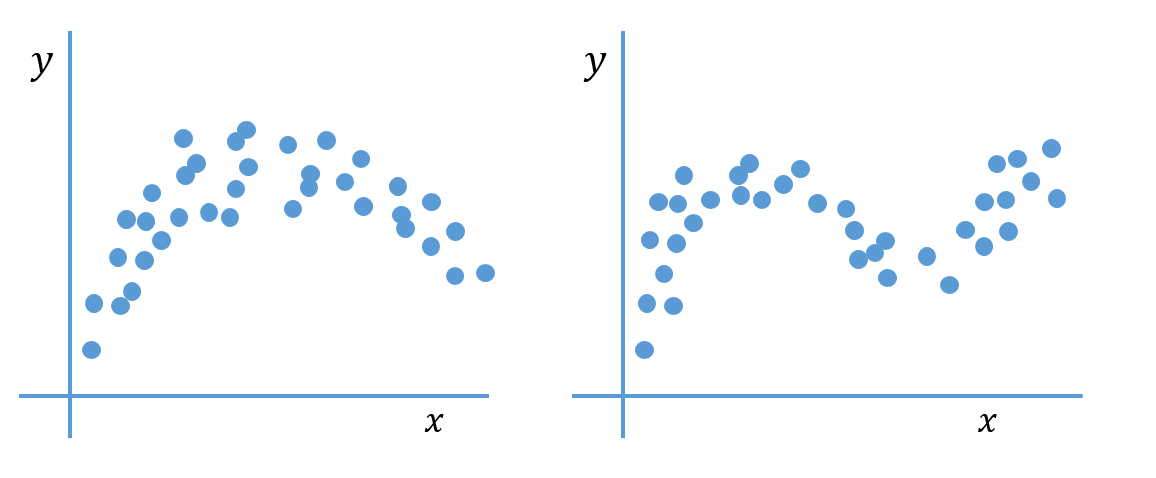

Шаг 1: Подключаем sklearn


Нам понадобится новый инструмент из sklearn, который возводит числа в степень.

In [ ]:
from sklearn.preprocessing import  PolynomialFeatures
# Этот инструмент превращает наше число x в набор [x, x^2, x^3...]

import numpy as np # это в папке Lesson_1 объяснено
import matplotlib.pyplot as plt # это в папке Lesson_1 объяснено
from sklearn.linear_model import LinearRegression # это в папке Lesson_1 объяснено

Шаг 2: Создаем данные (Кривая зависимость)


Давайте создадим данные, которые явно не похожи на прямую:

In [ ]:
x = np.array([[1], [2], [3], [4], [5]])
y = np.array([1, 4, 9, 16, 25]) 

Шаг 3: Магия трансформации


Здесь мы подготавливаем данные перед тем, как отдать их "мозгу".

In [ ]:
poly = PolynomialFeatures(degree=2) 
# degree=2 означает, что мы хотим добавить x во второй степени (квадрат).

x_poly = poly.fit_transform(x)
# Здесь происходит сама работа. 
# Эта команда состоит из двух действий: fit (изучить) и transform (изменить).
# Представьте, что у нас есть входное число x = 3. После этой строчки оно превратится в целую строку чисел: [1, 3, 9].
# (единица для смещения, само число 2 и его квадрат 4).

Шаг 4: Обучение (всё как раньше)


Теперь мы скармливаем нашей обычной линейной регрессии эти "прокачанные" данные.

In [ ]:
model = LinearRegression()
model.fit(x_poly, y);
# Мы обучаем модель на x_poly, поэтому она "видит" изгибы.

Для компьютера Полиномиальная регрессия — это и есть Линейная регрессия, просто над «хитрыми» данными.


Когда мы пишем:

__model = LinearRegression()__


__model.fit(x_poly, y)__


Мы говорим алгоритму: «Слушай, я подготовил для тебя таблицу x_poly. В ней есть обычные числа $x$ и их квадраты $x^2$, найди для них лучшие веса».

Как это видит ИИ: ИИ не знает, что $x^2$ — это квадрат числа $x$. Для него это просто еще один признак (как если бы мы добавили новую колонку, например, «влажность» к «температуре»). В теории ИИ: Мы строим уравнение $y = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2$.


На практике: Мы просто подставили вместо $x_2$ значение $x^2$. Математически зависимость между весами ($w$) всё еще линейная, поэтому мы используем инструмент LinearRegression(). Но так как один из признаков — это квадрат, на графике мы видим кривую.

Шаг 5: Визуализация результата


Чтобы увидеть красивую кривую, нам нужно предсказать значения для множества точек.

In [ ]:
x_range = np.linspace(0, 6, 100).reshape(-1, 1) # Берем 100 точек от 0 до 6
x_range_poly = poly.transform(x_range) # Обязательно трансформируем их тоже

y_pred = model.predict(x_range_poly)

plt.scatter(x, y, color='blue', label='Данные')
plt.plot(x_range, y_pred, color='green', label='Полином (степень 2)')
plt.title('ИИ научился изгибать линию!')
plt.legend()
plt.show()

---
Этот пример снизу был в презентации

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Устанавливаем шрифты
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. СОЗДАЕМ ДАННЫЕ
np.random.seed(42)
X = np.linspace(-3, 3, 30).reshape(-1, 1)
y_true = 0.5 * X.ravel()**3 - X.ravel()**2 + 2
y = y_true + np.random.normal(0, 2, size=X.shape[0])

# 2. СЕТКА ДЛЯ ВИЗУАЛИЗАЦИИ
X_test = np.linspace(-3.5, 3.5, 300).reshape(-1, 1)

# 3. НАСТРОЙКА СТЕПЕНЕЙ
degrees = [1, 2, 3, 4, 5, 7, 10]
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'magenta']

# Создаем сетку 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# Удаляем лишние ячейки (7 и 8)
fig.delaxes(axes[7])
fig.delaxes(axes[8])

fig.suptitle('Полиномиальная регрессия: влияние степени полинома', fontsize=16, fontweight='bold')

# 4. ЦИКЛ ПОСТРОЕНИЯ
for i, (degree, color) in enumerate(zip(degrees, colors)):
    ax = axes[i]
    
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    model.fit(X, y)
    y_pred = model.predict(X_test)
    
    # Визуализация данных
    ax.scatter(X, y, color='black', alpha=0.6, s=30, label='Данные')
    ax.plot(X_test, 0.5 * X_test.ravel()**3 - X_test.ravel()**2 + 2, 
            '--', color='gray', alpha=0.5, label='Истинная функция')
    ax.plot(X_test, y_pred, color=color, linewidth=3, label=f'Степень {degree}')
    
    # Настройка осей
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-15, 25)
    ax.set_title(f'Степень полинома: {degree}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # ГЕНЕРАЦИЯ ФОРМУЛЫ
    if degree == 1:
        formula_str = r'$\hat{y} = w_0 + w_1x$'
    elif degree == 2:
        formula_str = r'$\hat{y} = w_0 + w_1x + w_2x^2$'
    elif degree <= 4:
        parts = [r'w_{%d}x^{%d}' % (d, d) for d in range(1, degree + 1)]
        formula_str = r'$\hat{y} = w_0 + ' + ' + '.join(parts) + '$'
    else:
        formula_str = r'$\hat{y} = w_0 + w_1x + \dots + w_{%d}x^{%d}$' % (degree, degree)
    
    # Отрисовка формулы с увеличенным отступом (y=1.2)
    ax.text(0.5, 1.20, formula_str, transform=ax.transAxes, 
            fontsize=10, ha='center', va='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Общий комментарий снизу
plt.figtext(0.5, 0.01, 'Наблюдение: Степень 1 - недообучение, 3-4 - оптимально, 7+ - переобучение', 
            ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0.05, 1, 0.93]) # Настроили поля, чтобы формулы не обрезались
plt.show()

<div style="text-align: center;">
    <span style="color: orange; font-size: 32px; font-weight: bold;">Регуляризация (Lasso и Ridge)</span>
</div>

Что такое регуляризация?


Регуляризация (regularization) — это метод борьбы с переобучением (overfitting). Когда модель слишком точно подстраивается под обучающие данные, она начинает "запоминать" шум вместо того, чтобы выявлять общие закономерности. В результате на новых данных такая модель работает плохо.

Как это работает математически?


Регуляризация добавляет к функции ошибки (MSE) штраф за сложность модели. Чем больше веса у модели — тем больше штраф.

1. __Ridge (L2-регуляризация)__



_J(w) = MSE + λ * Σ w_j²_


Штрафует за квадраты весов

Стремится сделать веса маленькими, но не нулевыми

Хорошо работает, когда много признаков, и все они хоть немного полезны

2. __Lasso (L1-регуляризация)__


_J(w) = MSE + λ * Σ |w_j|_

Штрафует за абсолютные значения весов

Может обнулять веса — фактически отбирает признаки

Хорошо работает, когда нужно выбрать самые важные признаки

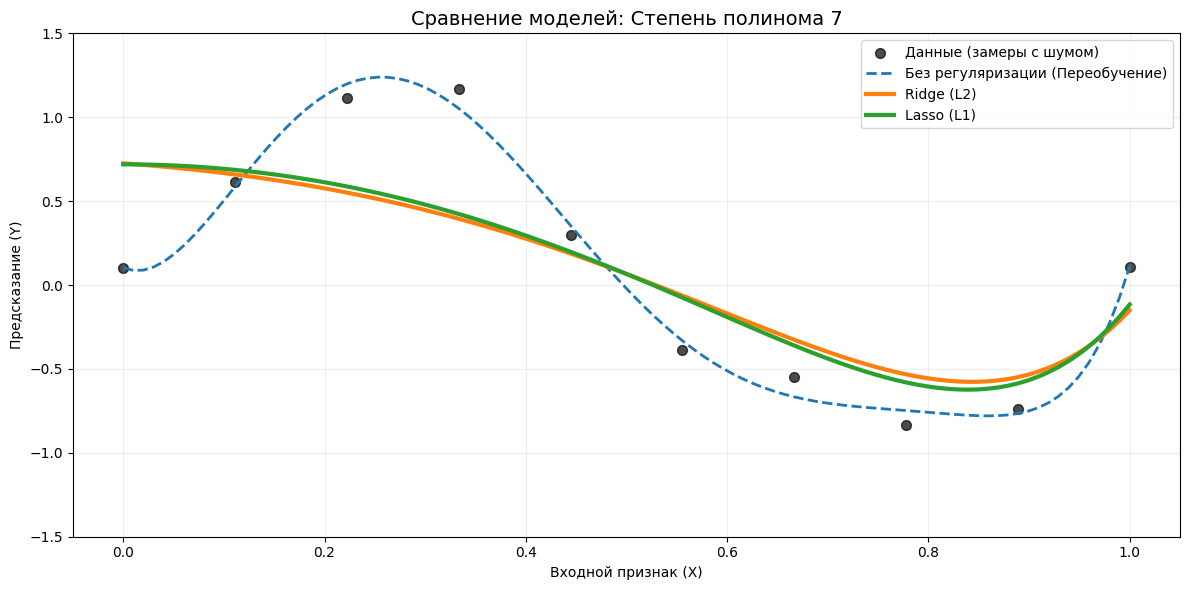

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


# 1. ГЕНЕРАЦИЯ ДАННЫХ
# Устанавливаем seed, чтобы результаты были одинаковыми при каждом запуске
np.random.seed(42)

# Создаём 10 точек от 0 до 1. reshape(-1, 1) превращает строку в столбец,
# потому что sklearn ожидает данные в формате "строки-признаки"
x = np.linspace(0, 1, 10).reshape(-1, 1)

# Генерируем ответы (y). 
# ПРИЧИНА ИСПОЛЬЗОВАНИЯ СИНУСА: Нам нужна нелинейная (изогнутая) форма данных, 
# чтобы проверить, как полиномы справляются со сложными зависимостями.
# Мы сразу добавляем случайный шум (np.random.normal), имитируя реальные измерения.
y = np.sin(2 * np.pi * x).ravel() + np.random.normal(0, 0.2, x.shape[0])

# Точки для построения графиков моделей (100 точек для плавности линий)
x_test = np.linspace(0, 1, 100).reshape(-1, 1)

# 2. СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛЕЙ
# Выбираем высокую степень полинома (7), чтобы спровоцировать переобучение
degree = 7

# Модель А: Обычная линейная регрессия (без ограничений)
# Она попытается максимально точно пройти через все точки с шумом.
model_simple = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_simple.fit(x, y)

# Модель Б: Ridge (L2-регуляризация)
# Добавляет штраф за КВАДРАТ весов. Это делает линию более плавной и устойчивой.
model_ridge = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=0.1))
model_ridge.fit(x, y)

# Модель В: Lasso (L1-регуляризация)
# Добавляет штраф за МОДУЛЬ весов. Может обнулять лишние признаки, упрощая модель.
model_lasso = make_pipeline(PolynomialFeatures(degree), Lasso(alpha=0.01))
model_lasso.fit(x, y)

# 3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
plt.figure(figsize=(12, 6))

# Рисуем исходные данные (черные точки с шумом)
plt.scatter(x, y, color='black', alpha=0.7, s=50, label='Данные (замеры с шумом)')

# Рисуем предсказания моделей 
plt.plot(x_test, model_simple.predict(x_test), '--', 
         label='Без регуляризации (Переобучение)', linewidth=2)

# Ridge (оранжевая): покажет сглаженную кривую
plt.plot(x_test, model_ridge.predict(x_test), 
         label='Ridge (L2)', linewidth=3)

# Lasso (зеленая): покажет упрощенную кривую
plt.plot(x_test, model_lasso.predict(x_test), 
         label='Lasso (L1)', linewidth=3)


plt.title(f'Сравнение моделей: Степень полинома {degree}', fontsize=14)
plt.xlabel('Входной признак (X)')
plt.ylabel('Предсказание (Y)')
plt.ylim(-1.5, 1.5) # Ограничение для фокуса на данных
plt.grid(True, alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()